In [1]:
import os
import time
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import optax
from jax.scipy.spatial.transform import Rotation
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState
from matplotlib import pyplot as plt

from lotf import LOTF_PATH
from lotf.envs import HoveringStateEnv, rollout
from lotf.envs.wrappers import MinMaxObservationWrapper
from lotf.modules import (
    MLP,
    LatentConditionedResidualDynamics,
    RecurrentTrajectoryEncoder,
)
from lotf.objects import Quadrotor

%matplotlib inline

# Joint Training of the Trajectory Encoder and Residual Dynamics

## 1. Seed

In [2]:
seed = 0
master_key = jax.random.key(seed)

# Give every stochastic stage its own reproducible stream. Unlike repeatedly
# splitting one mutable notebook key, these keys do not depend on cell reruns.
def experiment_key(stream_id):
    return jax.random.fold_in(master_key, stream_id)

key = master_key  # Kept only for compatibility with exploratory cells.

## 2. Define Simulation Dynamics Config

In [78]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": False,           # stand-in for the disturbed/real system
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# No residual parameters are read when use_forward_residual=False. Passing an
# empty pytree avoids restoring the legacy CUDA-sharded dummy checkpoint.
dummy_residual_params = {}

## 3. Create Quadrotor Object and Data-Collection Environment

In [79]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 5.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

eval_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,  # equation (2): v_dot += w
)
eval_env = MinMaxObservationWrapper(eval_env)

# get dims
action_dim = eval_env.action_space.shape[0]
obs_dim = eval_env.observation_space.shape[0]

print("====== eval_env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")

====== eval_env info ======
action_dim: 4
obs_dim: 27


## 4. Load the Trained Policy

In [80]:
policy_name = "state_hovering_params"

# create policy network
base_policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    action_bias=eval_env.hovering_action,
)

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
base_policy_params = ckptr.restore(path)
# define policy function
def policy_trained(obs, key):
    return base_policy_net.apply(base_policy_params, obs)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 5. Collect Rollouts with Fixed Wind Acceleration

In [91]:
# HoveringStateEnv samples one row from wind_z_table.csv at reset. We retain
# the sampled wind acceleration for the whole rollout but ignore the paired
# CSV latent completely: the encoder must infer its own condition online.
num_rollouts = 256
key_rollouts = experiment_key(1)
rollout_keys = jax.random.split(key_rollouts, num_rollouts)
parallel_rollout = jax.vmap(rollout, in_axes=(None, 0, None, None))
trajectories = parallel_rollout(
    eval_env, rollout_keys, policy_trained, dummy_residual_params
)

env_states = trajectories.state
quad_states = env_states.quadrotor_state

# Convert rotation matrices to the paper's state convention: (p, q, v).
def state_vectors(position, rotation_matrix, velocity):
    quaternion_xyzw = Rotation.from_matrix(rotation_matrix).as_quat()
    quaternion_wxyz = jnp.concatenate(
        [quaternion_xyzw[..., 3:], quaternion_xyzw[..., :3]], axis=-1
    )
    return jnp.concatenate([position, quaternion_wxyz, velocity], axis=-1)

states = state_vectors(
    quad_states.p[:, :-1], quad_states.R[:, :-1], quad_states.v[:, :-1]
)
# The action chosen from s_t is stored at the end of the successor state's
# action buffer, hence the 1: alignment below.
actions = env_states.last_actions[:, 1:, -1, :]
hidden_acceleration = env_states.hidden_acceleration[:, :-1, :]
state_actions = jnp.concatenate([states, actions], axis=-1)

# rollout(..., real_step=False) does not auto-reset. Keep the terminal
# transition itself, but discard any subsequent out-of-episode transitions.
done = jnp.logical_or(
    trajectories.terminated[:, 1:], trajectories.truncated[:, 1:]
)
valid_transition = (jnp.cumsum(done, axis=1) - done) == 0

assert states.shape[-1] == 10
assert actions.shape[-1] == 4
assert state_actions.shape[-1] == 14
assert jnp.all(hidden_acceleration == hidden_acceleration[:, :1, :])

_, rollouts_per_condition = jnp.unique(
    hidden_acceleration[:, 0, :], axis=0, return_counts=True
)
print(f"Collected {valid_transition.sum():,} valid transitions")
print(f"Conditions represented: {rollouts_per_condition.shape[0]}/17")
print(f"Rollouts per represented condition: {rollouts_per_condition}")

Collected 64,000 valid transitions
Conditions represented: 17/17
Rollouts per represented condition: [12  8 14 21 18 11 15 17 18 19 15 13 14 13 15 16 17]


## 6. Build Rolling Contexts and Residual Targets

In [92]:
# The paper defines H_{t-C:t} from the C state-action pairs immediately before
# transition t. A new rolling context therefore produces a new z_t at every
# timestep. One z_t is shared over several following transitions so it must
# represent their common dynamics instead of memorizing a single residual.
context_length = 20
dynamics_horizon = 20
train_fraction = 0.9

num_transitions_per_rollout = state_actions.shape[1]
num_contexts_per_rollout = (
    num_transitions_per_rollout - context_length - dynamics_horizon + 1
)
assert num_contexts_per_rollout > 0

# Split whole rollouts before normalization or windowing. Overlapping windows
# from a rollout can therefore never appear in both training and validation.
key_split = experiment_key(2)
rollout_permutation = jax.random.permutation(key_split, num_rollouts)
num_train_rollouts = int(train_fraction * num_rollouts)
train_rollout_indices = rollout_permutation[:num_train_rollouts]
train_rollout_mask = jnp.zeros(num_rollouts, dtype=bool)
train_rollout_mask = train_rollout_mask.at[train_rollout_indices].set(True)

normalization_mask = train_rollout_mask[:, None] & valid_transition
input_mean = state_actions[normalization_mask].mean(axis=0)
input_std = jnp.maximum(
    state_actions[normalization_mask].std(axis=0), 1e-6
)
normalized_state_actions = (state_actions - input_mean) / input_std

context_transition_indices = (
    jnp.arange(num_contexts_per_rollout)[:, None]
    + jnp.arange(context_length)[None, :]
)
target_transition_indices = (
    jnp.arange(num_contexts_per_rollout)[:, None]
    + context_length
    + jnp.arange(dynamics_horizon)[None, :]
)

rolling_contexts = normalized_state_actions[:, context_transition_indices]
rolling_dynamics_inputs = normalized_state_actions[:, target_transition_indices]
context_valid = valid_transition[:, context_transition_indices].all(axis=-1)
targets_valid = valid_transition[:, target_transition_indices].all(axis=-1)
valid_context = context_valid & targets_valid

contexts = rolling_contexts[valid_context]
dynamics_inputs = rolling_dynamics_inputs[valid_context]
context_rollout_grid = jnp.broadcast_to(
    jnp.arange(num_rollouts)[:, None], valid_context.shape
)
context_time_grid = jnp.broadcast_to(
    (jnp.arange(num_contexts_per_rollout) + context_length)[None, :],
    valid_context.shape,
)
context_rollout_ids = context_rollout_grid[valid_context]
context_times = context_time_grid[valid_context]

# Evaluate the nominal rigid-body prior on every target transition. Its delay
# remains identical to the data-collection environment.
prior_dyn_config = {
    "use_high_fidelity": False,
    "use_forward_residual": False,
}
prior_env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    quad_obj=Quadrotor.from_name("example_quad", prior_dyn_config),
    apply_hidden_acceleration=False,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

transition_states = jax.tree.map(
    lambda leaf: leaf[:, :num_transitions_per_rollout].reshape(
        (-1,) + leaf.shape[2:]
    ),
    env_states,
)
observed_next_quad_states = jax.tree.map(
    lambda leaf: leaf[:, 1:num_transitions_per_rollout + 1].reshape(
        (-1,) + leaf.shape[2:]
    ),
    quad_states,
)
prior_actions = actions.reshape(-1, action_dim)
key_prior = experiment_key(3)
prior_keys = jax.random.split(key_prior, prior_actions.shape[0])

@jax.jit
def evaluate_prior(prior_states, prior_actions, prior_keys):
    def prior_step(state, action, step_key):
        transition = prior_env._step(state, action, {}, step_key)
        return transition.state.quadrotor_state

    return jax.vmap(prior_step)(prior_states, prior_actions, prior_keys)

# Evaluate each physical transition once in fixed-size batches. Repeating
# transitions through all overlapping windows caused the previous OOM.
prior_batch_size = 2048
num_prior_transitions = prior_actions.shape[0]
num_padded_prior_transitions = (
    (num_prior_transitions + prior_batch_size - 1) // prior_batch_size
    * prior_batch_size
)
prior_padding_indices = jnp.minimum(
    jnp.arange(num_padded_prior_transitions),
    num_prior_transitions - 1,
)
padded_transition_states = jax.tree.map(
    lambda leaf: leaf[prior_padding_indices], transition_states
)
padded_prior_actions = prior_actions[prior_padding_indices]
padded_prior_keys = prior_keys[prior_padding_indices]
prior_output_chunks = []
for batch_start in range(0, num_padded_prior_transitions, prior_batch_size):
    batch_stop = batch_start + prior_batch_size
    prior_output_chunks.append(evaluate_prior(
        jax.tree.map(
            lambda leaf: leaf[batch_start:batch_stop],
            padded_transition_states,
        ),
        padded_prior_actions[batch_start:batch_stop],
        padded_prior_keys[batch_start:batch_stop],
    ))
prior_next_quad_states = jax.tree.map(
    lambda *chunks: jnp.concatenate(chunks, axis=0)[:num_prior_transitions],
    *prior_output_chunks,
)

def state_difference(observed, nominal):
    # Hovering predicts translational residuals only. Orientation is advanced
    # entirely by the analytical body-rate dynamics in the physics prior.
    return jnp.concatenate(
        [observed.p - nominal.p, observed.v - nominal.v], axis=-1
    )

transition_residual_targets = state_difference(
    observed_next_quad_states, prior_next_quad_states
).reshape(num_rollouts, num_transitions_per_rollout, -1)
residual_targets = (
    transition_residual_targets[:, target_transition_indices][valid_context]
)
assert residual_targets.shape[-1] == 6

training_context_mask = train_rollout_mask[context_rollout_ids]
train_contexts = contexts[training_context_mask]
train_dynamics_inputs = dynamics_inputs[training_context_mask]
train_targets = residual_targets[training_context_mask]
validation_contexts = contexts[~training_context_mask]
validation_dynamics_inputs = dynamics_inputs[~training_context_mask]
validation_targets = residual_targets[~training_context_mask]
validation_rollout_ids = context_rollout_ids[~training_context_mask]
validation_context_times = context_times[~training_context_mask]
train_targets.block_until_ready()
validation_targets.block_until_ready()
del rolling_contexts, rolling_dynamics_inputs, normalized_state_actions
del transition_states, observed_next_quad_states, prior_next_quad_states
del padded_transition_states, padded_prior_actions, padded_prior_keys
del prior_output_chunks, transition_residual_targets, prior_padding_indices
jax.clear_caches()
print(f"Training rollouts:   {num_train_rollouts}")
print(f"Validation rollouts: {num_rollouts - num_train_rollouts}")
print(f"Training contexts:   {train_contexts.shape[0]:,}")
print(f"Validation contexts: {validation_contexts.shape[0]:,}")
print(f"Context shape:       {train_contexts.shape[1:]}")
print(f"Targets per latent:  {dynamics_horizon}")


Training rollouts:   230
Validation rollouts: 26
Training contexts:   48,530
Validation contexts: 5,486
Context shape:       (20, 14)
Targets per latent:  20


## 7. Create the Encoder, Decoder, and FiLM Residual Dynamics

In [93]:
state_action_dim = state_actions.shape[-1]
latent_dim = 12

trajectory_encoder = RecurrentTrajectoryEncoder(
    state_action_dim=state_action_dim,
    context_length=context_length,
    latent_dim=latent_dim,
    projection_dim=128,
    hidden_dim=128,
)
residual_model = LatentConditionedResidualDynamics(
    state_action_dim=state_action_dim,
    latent_dim=latent_dim,
    hidden_dim=256,
    num_blocks=2,
    predict_orientation=False,
)
# G_eta is auxiliary: it reconstructs the complete normalized context from z.
context_decoder = MLP(
    [latent_dim, 256, 256, context_length * state_action_dim],
    nonlinearity=jax.nn.gelu,
)

key_encoder, key_residual, key_decoder = jax.random.split(
    experiment_key(4), 3
)
initial_joint_params = {
    "encoder": trajectory_encoder.initialize(key_encoder),
    "residual": residual_model.initialize(key_residual),
    "decoder": context_decoder.initialize(key_decoder),
}

def joint_forward(params, contexts, normalized_dynamics_inputs):
    latents = trajectory_encoder.apply(params["encoder"], contexts)
    expanded_latents = jnp.broadcast_to(
        latents[..., None, :],
        normalized_dynamics_inputs.shape[:-1] + (latent_dim,),
    )
    predicted_residuals = residual_model.apply(
        params["residual"], normalized_dynamics_inputs, expanded_latents
    )
    reconstructed_contexts = context_decoder.apply(
        params["decoder"], latents
    ).reshape(contexts.shape)
    return latents, predicted_residuals, reconstructed_contexts

dummy_latent, dummy_residuals, dummy_reconstruction = joint_forward(
    initial_joint_params, train_contexts[0], train_dynamics_inputs[0]
)
assert dummy_latent.shape == (latent_dim,)
assert dummy_residuals.shape == (dynamics_horizon, 6)
assert dummy_reconstruction.shape == (context_length, state_action_dim)
print(f"Encoder output:        {dummy_latent.shape}")
print(f"Residual-head output: {dummy_residuals.shape}")
print(f"Decoder output:        {dummy_reconstruction.shape}")


Encoder output:        (12,)
Residual-head output: (20, 6)
Decoder output:        (20, 14)


## 8. Joint Training with Normalized Residual Targets

In [101]:
# Compute target statistics from training rollouts only. Each of the six output
# coordinates is standardized independently; validation data never contributes.
# lambda_rec is exposed explicitly because the paper does not prescribe one
# universal task-independent value. L_rec acts on normalized context channels.
lambda_rec = 1e-4
huber_delta = 1.0
batch_size = min(128, train_contexts.shape[0])
num_training_steps = 10000
steps_per_training_chunk = 100
print_every = 100  # Set to 1 to print every optimizer update.
assert num_training_steps % steps_per_training_chunk == 0

residual_target_mean = train_targets.mean(axis=(0, 1))
residual_target_std = jnp.maximum(
    train_targets.std(axis=(0, 1)), 1e-8
)
normalized_train_targets = (
    train_targets - residual_target_mean
) / residual_target_std
normalized_validation_targets = (
    validation_targets - residual_target_mean
) / residual_target_std

component_names = [
    "delta_p_x", "delta_p_y", "delta_p_z",
    "delta_v_x", "delta_v_y", "delta_v_z",
]

print("Training residual-target statistics:")
for name, mean, std in zip(
    component_names, residual_target_mean, residual_target_std
):
    print(f"  {name:>10s}: mean={mean:.6e}, std={std:.6e}")

# Initialize the target-normalized encoder, residual dynamics, and decoder.
target_normalized_train_state = TrainState.create(
    apply_fn=joint_forward,
    params=initial_joint_params,
    tx=optax.adam(learning_rate=3e-4),
)

def target_normalized_joint_loss(
    params, contexts, dynamics_inputs, normalized_targets
):
    _, normalized_predictions, reconstructions = joint_forward(
        params, contexts, dynamics_inputs
    )
    dynamics_loss = optax.huber_loss(
        normalized_predictions, normalized_targets, delta=huber_delta
    ).mean()
    # Equation (16): average the per-context squared L2 norm. Sum over
    # context time and feature dimensions, then average over the batch.
    reconstruction_loss = jnp.sum(
        jnp.square(reconstructions - contexts), axis=(-2, -1)
    ).mean()
    total_loss = dynamics_loss + lambda_rec * reconstruction_loss
    return total_loss, (dynamics_loss, reconstruction_loss)

@jax.jit
def train_target_normalized_chunk(train_state, rng_key, first_step):
    def training_step(carry, step):
        state, step_key = carry
        step_key, sample_key = jax.random.split(step_key)
        batch_indices = jax.random.randint(
            sample_key, (batch_size,), 0, train_contexts.shape[0]
        )
        (loss, (dyn_loss, rec_loss)), gradients = jax.value_and_grad(
            target_normalized_joint_loss, has_aux=True
        )(
            state.params,
            train_contexts[batch_indices],
            train_dynamics_inputs[batch_indices],
            normalized_train_targets[batch_indices],
        )
        state = state.apply_gradients(grads=gradients)

        def print_current_losses(_):
            jax.debug.print(
                "Target-normalized training step {}", step, ordered=True
            )
            jax.debug.print("L_dyn: {}", dyn_loss, ordered=True)
            jax.debug.print("L_rec: {}", rec_loss, ordered=True)
            jax.debug.print(
                "weighted L_rec: {}",
                lambda_rec * rec_loss,
                ordered=True,
            )
            return jnp.int32(0)

        should_print = (step % print_every == 0) | (
            step == num_training_steps - 1
        )
        jax.lax.cond(
            should_print,
            print_current_losses,
            lambda _: jnp.int32(0),
            operand=None,
        )
        loss_components = jnp.stack([loss, dyn_loss, rec_loss])
        return (state, step_key), loss_components

    (train_state, rng_key), losses = jax.lax.scan(
        training_step,
        (train_state, rng_key),
        first_step + jnp.arange(steps_per_training_chunk),
    )
    return train_state, rng_key, losses

target_normalized_initial_total, (
    target_normalized_initial_dyn,
    target_normalized_initial_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    train_contexts[:batch_size],
    train_dynamics_inputs[:batch_size],
    normalized_train_targets[:batch_size],
)
# Use the same fixed minibatch-index stream on every execution of this cell.
key_target_normalized_train = experiment_key(5)
compiled_train_target_normalized_chunk = train_target_normalized_chunk.lower(
    target_normalized_train_state,
    key_target_normalized_train,
    jnp.asarray(0),
).compile()
target_normalized_training_start = time.perf_counter()
target_normalized_loss_chunks = []
num_training_chunks = num_training_steps // steps_per_training_chunk
for training_chunk in range(num_training_chunks):
    first_step = jnp.asarray(training_chunk * steps_per_training_chunk)
    (
        target_normalized_train_state,
        key_target_normalized_train,
        chunk_losses,
    ) = compiled_train_target_normalized_chunk(
        target_normalized_train_state,
        key_target_normalized_train,
        first_step,
    )
    chunk_losses.block_until_ready()
    target_normalized_loss_chunks.append(chunk_losses)
target_normalized_training_losses = jnp.concatenate(
    target_normalized_loss_chunks, axis=0
)
target_normalized_training_duration = (
    time.perf_counter() - target_normalized_training_start
)
target_normalized_validation_total, (
    target_normalized_validation_dyn,
    target_normalized_validation_rec,
) = target_normalized_joint_loss(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
    normalized_validation_targets,
)

print(f"Initial normalized-target total: {target_normalized_initial_total:.6e}")
print(f"Initial normalized L_dyn:        {target_normalized_initial_dyn:.6e}")
print(f"Initial L_rec:                   {target_normalized_initial_rec:.6e}")
print(
    f"Final normalized-target total:   "
    f"{target_normalized_training_losses[-1, 0]:.6e}"
)
print(
    f"Final normalized L_dyn:          "
    f"{target_normalized_training_losses[-1, 1]:.6e}"
)
print(
    f"Final L_rec:                     "
    f"{target_normalized_training_losses[-1, 2]:.6e}"
)
print(f"Validation normalized L_dyn:     {target_normalized_validation_dyn:.6e}")
print(f"Validation L_rec:                {target_normalized_validation_rec:.6e}")
print(f"Training time:                   {target_normalized_training_duration:.2f} s")


Training residual-target statistics:
   delta_p_x: mean=1.393465e-05, std=2.144420e-04
   delta_p_y: mean=-3.434963e-06, std=2.184684e-04
   delta_p_z: mean=0.000000e+00, std=1.000000e-08
   delta_v_x: mean=1.393116e-03, std=2.144291e-02
   delta_v_y: mean=-3.434559e-04, std=2.184658e-02
   delta_v_z: mean=0.000000e+00, std=1.000000e-08
Target-normalized training step 0
L_dyn: 0.3031078577041626
L_rec: 239.34771728515625
weighted L_rec: 0.02393477037549019
Target-normalized training step 100
L_dyn: 0.0036044479347765446
L_rec: 108.0373764038086
weighted L_rec: 0.010803737677633762
Target-normalized training step 200
L_dyn: 0.001778695615939796
L_rec: 25.10822296142578
weighted L_rec: 0.002510822145268321
Target-normalized training step 300
L_dyn: 0.0021648991387337446
L_rec: 41.845359802246094
weighted L_rec: 0.004184535704553127
Target-normalized training step 400
L_dyn: 0.0012035089312121272
L_rec: 17.715972900390625
weighted L_rec: 0.0017715971916913986
Target-normalized training st

## 9. Plot Target-Normalized Training Losses

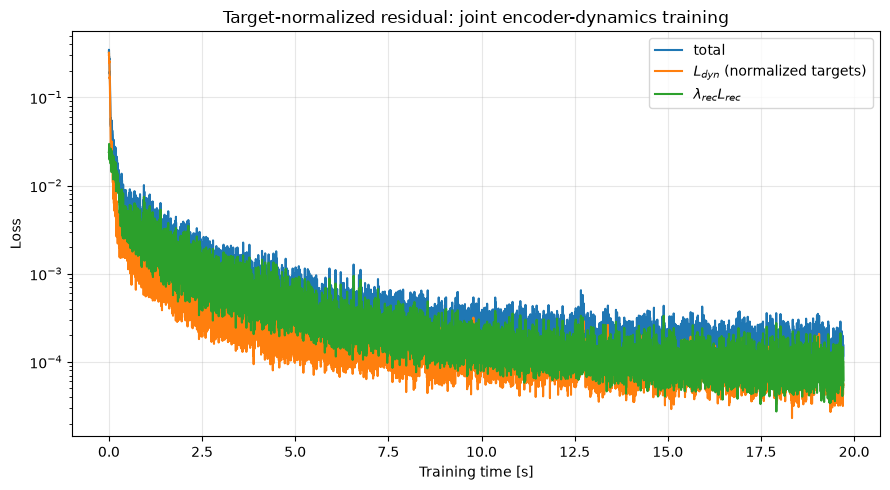

In [102]:
target_normalized_training_time_axis = jnp.linspace(
    0.0, target_normalized_training_duration, num_training_steps
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 0],
    label="total",
)
ax.plot(
    target_normalized_training_time_axis,
    target_normalized_training_losses[:, 1],
    label=r"$L_{dyn}$ (normalized targets)",
)
ax.plot(
    target_normalized_training_time_axis,
    lambda_rec * target_normalized_training_losses[:, 2],
    label=r"$\lambda_{rec} L_{rec}$",
)
ax.set_yscale("log")
ax.set_xlabel("Training time [s]")
ax.set_ylabel("Loss")
ax.set_title("Target-normalized residual: joint encoder-dynamics training")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 10. Collect Fresh Validation Rollouts

In [103]:
# This is a genuinely fresh evaluation dataset. Nothing in this cell updates
# the policy, encoder, decoder, or residual-dynamics parameters.
num_one_step_rollouts = 32
open_loop_validation_time = 5.0
one_step_num_steps = context_length + int(round(
    open_loop_validation_time / sim_dt
))
one_step_eval_env = HoveringStateEnv(
    max_steps_in_episode=one_step_num_steps,
    dt=sim_dt,
    delay=0.04,
    quad_obj=quad_obj,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
    apply_hidden_acceleration=True,
)
one_step_eval_env = MinMaxObservationWrapper(one_step_eval_env)
key_one_step_rollouts = experiment_key(6)
one_step_rollout_keys = jax.random.split(
    key_one_step_rollouts, num_one_step_rollouts
)
one_step_trajectories = parallel_rollout(
    one_step_eval_env,
    one_step_rollout_keys,
    policy_trained,
    dummy_residual_params,
)

one_step_env_states = one_step_trajectories.state
one_step_quad_states = one_step_env_states.quadrotor_state
one_step_states = state_vectors(
    one_step_quad_states.p[:, :-1],
    one_step_quad_states.R[:, :-1],
    one_step_quad_states.v[:, :-1],
)
one_step_actions = one_step_env_states.last_actions[:, 1:, -1, :]
one_step_state_actions = jnp.concatenate(
    [one_step_states, one_step_actions], axis=-1
)
one_step_normalized_state_actions = (
    one_step_state_actions - input_mean
) / input_std

one_step_done = jnp.logical_or(
    one_step_trajectories.terminated[:, 1:],
    one_step_trajectories.truncated[:, 1:],
)
one_step_valid_transition = (
    jnp.cumsum(one_step_done, axis=1) - one_step_done
) == 0
num_one_step_contexts = (
    one_step_state_actions.shape[1] - context_length
)
one_step_context_indices = (
    jnp.arange(num_one_step_contexts)[:, None]
    + jnp.arange(context_length)[None, :]
)
one_step_target_indices = (
    jnp.arange(num_one_step_contexts) + context_length
)
one_step_valid_context = (
    one_step_valid_transition[:, one_step_context_indices].all(axis=-1)
    & one_step_valid_transition[:, one_step_target_indices]
)

one_step_contexts = one_step_normalized_state_actions[
    :, one_step_context_indices
][one_step_valid_context]
one_step_inputs = one_step_normalized_state_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_current_states = one_step_states[
    :, one_step_target_indices
][one_step_valid_context]
one_step_target_actions = one_step_actions[
    :, one_step_target_indices
][one_step_valid_context]
one_step_hidden_accelerations = one_step_env_states.hidden_acceleration[
    :, one_step_target_indices
][one_step_valid_context]
assert jnp.all(
    one_step_env_states.hidden_acceleration
    == one_step_env_states.hidden_acceleration[:, :1, :]
)

# Run the analytical prior once from each measured pre-transition state.
one_step_prior_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices][one_step_valid_context],
    one_step_env_states,
)
one_step_observed_next_states = jax.tree.map(
    lambda leaf: leaf[:, one_step_target_indices + 1][one_step_valid_context],
    one_step_quad_states,
)
key_one_step_prior = experiment_key(7)
one_step_prior_keys = jax.random.split(
    key_one_step_prior, one_step_inputs.shape[0]
)
one_step_prior_next_states = evaluate_prior(
    one_step_prior_states,
    one_step_target_actions,
    one_step_prior_keys,
)
one_step_targets = state_difference(
    one_step_observed_next_states, one_step_prior_next_states
)
one_step_next_states = state_vectors(
    one_step_observed_next_states.p,
    one_step_observed_next_states.R,
    one_step_observed_next_states.v,
)

# Labels shared by one-step and open-loop validation.
head_slices = [slice(0, 3), slice(3, 6)]
head_labels = ["position", "velocity"]
head_units = ["m", "m/s"]
held_out_rollouts_to_plot = jnp.unique(validation_rollout_ids)[:4]

# Nominal errors are the baseline for the normalized model's learned correction.
nominal_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.p - one_step_observed_next_states.p
)))
nominal_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    one_step_prior_next_states.v - one_step_observed_next_states.v
)))
print(f"Fresh one-step samples: {one_step_inputs.shape[0]:,}")


Fresh one-step samples: 8,000


## 11. Evaluate Target-Normalized One-Step Predictions

Held-out physical residual errors (target-normalized training):
   delta_p_x: MAE=4.219228e-06, RMSE=9.028130e-06
   delta_p_y: MAE=4.040252e-06, RMSE=7.644791e-06
   delta_p_z: MAE=1.381175e-11, RMSE=2.546818e-11
   delta_v_x: MAE=4.190579e-04, RMSE=8.975550e-04
   delta_v_y: MAE=4.038364e-04, RMSE=7.546205e-04
   delta_v_z: MAE=1.547050e-11, RMSE=2.768477e-11

Fresh one-step errors (target-normalized training):
Normalized-target L_dyn: 1.009273e-03
   delta_p_x: MAE=4.359864e-06, RMSE=1.004242e-05
   delta_p_y: MAE=5.322219e-06, RMSE=1.389069e-05
   delta_p_z: MAE=1.925558e-11, RMSE=4.053148e-11
   delta_v_x: MAE=4.337022e-04, RMSE=9.706786e-04
   delta_v_y: MAE=5.291947e-04, RMSE=1.344843e-03
   delta_v_z: MAE=1.842907e-11, RMSE=4.517840e-11
Physical one-step RMSE before -> after target-normalized correction:
  position: 1.744063e-04 -> 9.896450e-06 m
  velocity: 1.744037e-02 -> 9.575699e-04 m/s


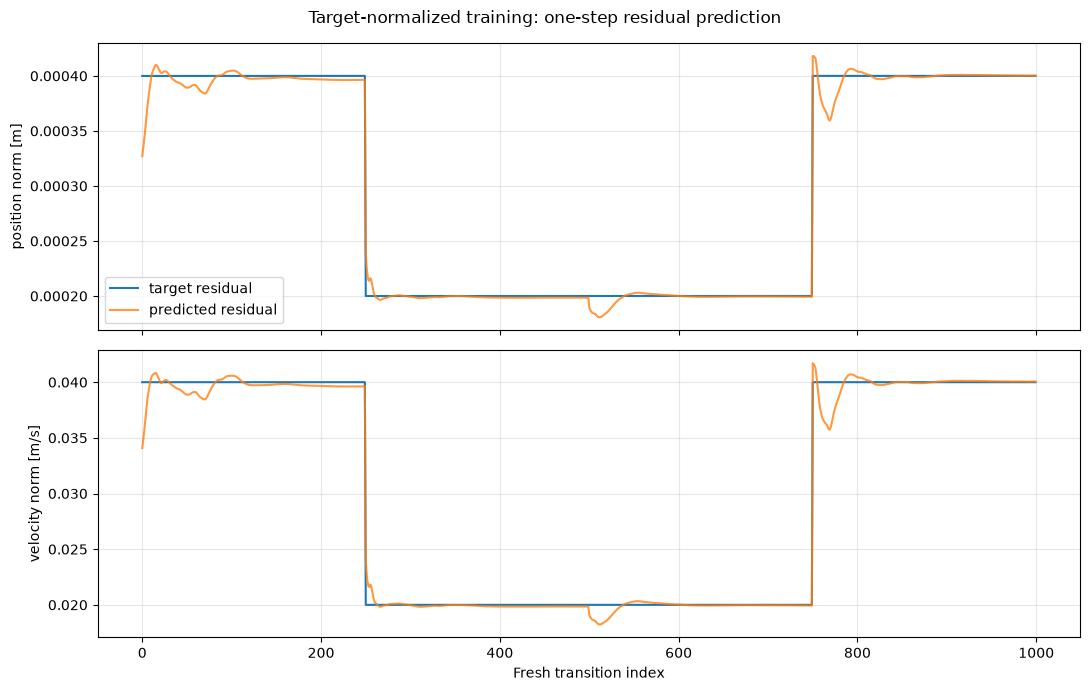

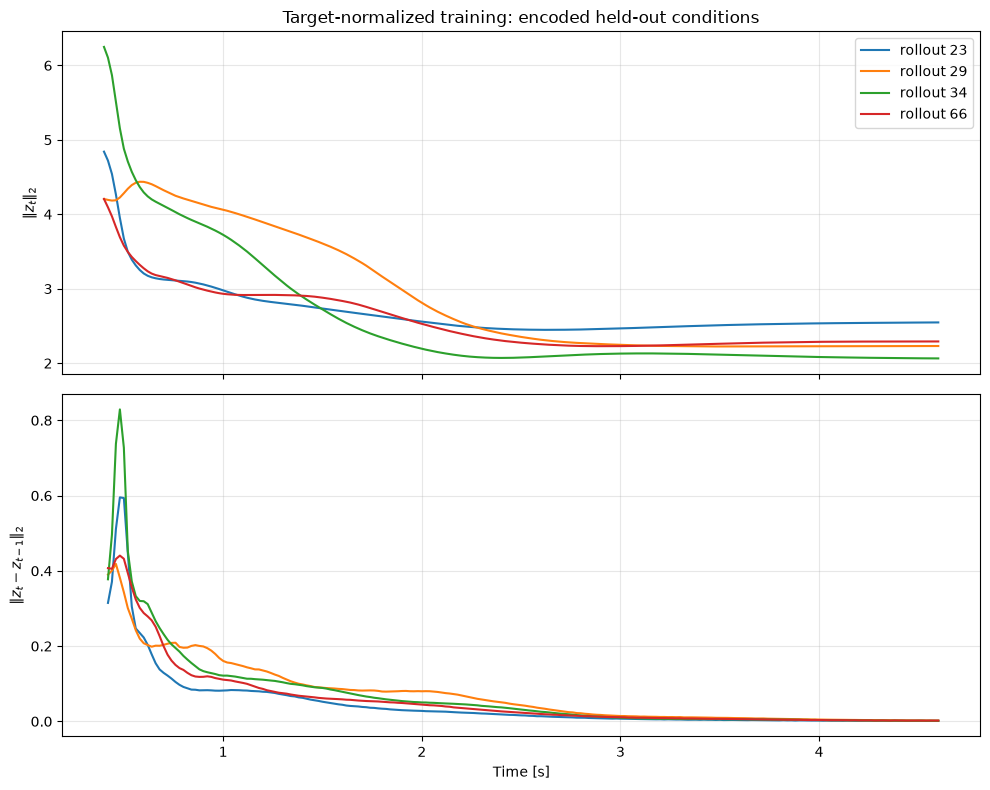

In [104]:
# Held-out contexts from the original rollout-wise split. Convert model outputs
# back to physical residual units before reporting errors.
(
    target_normalized_validation_latents,
    target_normalized_validation_predictions_norm,
    _,
) = joint_forward(
    target_normalized_train_state.params,
    validation_contexts,
    validation_dynamics_inputs,
)
target_normalized_validation_predictions = (
    target_normalized_validation_predictions_norm * residual_target_std
    + residual_target_mean
)
target_normalized_validation_predictions.block_until_ready()
target_normalized_validation_errors = (
    target_normalized_validation_predictions - validation_targets
)
target_normalized_component_mae = jnp.abs(
    target_normalized_validation_errors
).mean(axis=(0, 1))
target_normalized_component_rmse = jnp.sqrt(jnp.square(
    target_normalized_validation_errors
).mean(axis=(0, 1)))

print("Held-out physical residual errors (target-normalized training):")
for name, mae, rmse in zip(
    component_names,
    target_normalized_component_mae,
    target_normalized_component_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")

# Evaluate the fresh one-step dataset collected in the preceding section.
target_normalized_one_step_latents = trajectory_encoder.apply(
    target_normalized_train_state.params["encoder"], one_step_contexts
)
target_normalized_one_step_predictions_norm = residual_model.apply(
    target_normalized_train_state.params["residual"],
    one_step_inputs,
    target_normalized_one_step_latents,
)
target_normalized_one_step_predictions = (
    target_normalized_one_step_predictions_norm * residual_target_std
    + residual_target_mean
)
one_step_dataset = {
    "context": one_step_contexts,
    "state": one_step_current_states,
    "action": one_step_target_actions,
    "next_state": one_step_next_states,
    "normalized_state_action": one_step_inputs,
    "target_residual": one_step_targets,
    "predicted_residual": target_normalized_one_step_predictions,
    "encoded_latent": target_normalized_one_step_latents,
    "hidden_acceleration_diagnostic": one_step_hidden_accelerations,
}
target_normalized_one_step_errors = (
    target_normalized_one_step_predictions - one_step_targets
)
target_normalized_one_step_mae = jnp.abs(
    target_normalized_one_step_errors
).mean(axis=0)
target_normalized_one_step_rmse = jnp.sqrt(jnp.square(
    target_normalized_one_step_errors
).mean(axis=0))
target_normalized_one_step_huber = optax.huber_loss(
    target_normalized_one_step_predictions_norm,
    (one_step_targets - residual_target_mean) / residual_target_std,
    delta=huber_delta,
).mean()

target_normalized_corrected_positions = (
    one_step_prior_next_states.p
    + target_normalized_one_step_predictions[:, :3]
)
target_normalized_corrected_velocities = (
    one_step_prior_next_states.v
    + target_normalized_one_step_predictions[:, 3:6]
)
target_normalized_corrected_position_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_positions - one_step_observed_next_states.p
)))
target_normalized_corrected_velocity_rmse = jnp.sqrt(jnp.mean(jnp.square(
    target_normalized_corrected_velocities - one_step_observed_next_states.v
)))

print("\nFresh one-step errors (target-normalized training):")
print(f"Normalized-target L_dyn: {target_normalized_one_step_huber:.6e}")
for name, mae, rmse in zip(
    component_names,
    target_normalized_one_step_mae,
    target_normalized_one_step_rmse,
):
    print(f"  {name:>10s}: MAE={mae:.6e}, RMSE={rmse:.6e}")
print("Physical one-step RMSE before -> after target-normalized correction:")
print(
    f"  position: {nominal_position_rmse:.6e} -> "
    f"{target_normalized_corrected_position_rmse:.6e} m"
)
print(
    f"  velocity: {nominal_velocity_rmse:.6e} -> "
    f"{target_normalized_corrected_velocity_rmse:.6e} m/s"
)

num_target_normalized_plot_samples = min(
    1000, one_step_inputs.shape[0]
)
target_normalized_plot_indices = jnp.arange(
    num_target_normalized_plot_samples
)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, head_slice, head_label, head_unit in zip(
    axes, head_slices, head_labels, head_units
):
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            one_step_targets[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="target residual",
    )
    ax.plot(
        target_normalized_plot_indices,
        jnp.linalg.norm(
            target_normalized_one_step_predictions[
                :num_target_normalized_plot_samples, head_slice
            ],
            axis=-1,
        ),
        label="predicted residual",
        alpha=0.8,
    )
    ax.set_ylabel(f"{head_label} norm [{head_unit}]")
    ax.grid(True, alpha=0.3)
axes[0].legend()
axes[-1].set_xlabel("Fresh transition index")
fig.suptitle(
    "Target-normalized training: one-step residual prediction"
)
fig.tight_layout()
plt.show()

# Show how the newly trained encoder varies across held-out real contexts.
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for rollout_id in held_out_rollouts_to_plot:
    rollout_mask = validation_rollout_ids == rollout_id
    rollout_time = validation_context_times[rollout_mask] * sim_dt
    rollout_latents = target_normalized_validation_latents[rollout_mask]
    axes[0].plot(
        rollout_time,
        jnp.linalg.norm(rollout_latents, axis=-1),
        label=f"rollout {int(rollout_id)}",
    )
    axes[1].plot(
        rollout_time[1:],
        jnp.linalg.norm(
            rollout_latents[1:] - rollout_latents[:-1], axis=-1
        ),
    )
axes[0].set_ylabel(r"$\|z_t\|_2$")
axes[0].set_title(
    "Target-normalized training: encoded held-out conditions"
)
axes[0].legend()
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel(r"$\|z_t-z_{t-1}\|_2$")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 12. Prepare the Five-Second Open-Loop Evaluation

In [108]:
# Match the paper's dynamics evaluation: infer one latent from the measured
# context, then hold it fixed while recursively replaying the same recorded
# action sequence from the same measured initial state.
open_loop_horizon = int(round(open_loop_validation_time / sim_dt))
max_open_loop_rollouts = 8
assert context_length + open_loop_horizon <= one_step_state_actions.shape[1]

# Rank rollouts by their valid post-context duration. State targets after an
# actual trajectory terminates are masked rather than treated as observations.
open_loop_context_valid = one_step_valid_transition[
    :, :context_length
].all(axis=1)
open_loop_available_steps = one_step_valid_transition[
    :, context_length:context_length + open_loop_horizon
].sum(axis=1)
open_loop_scores = jnp.where(
    open_loop_context_valid, open_loop_available_steps, -1
)
open_loop_rollout_indices = jnp.argsort(open_loop_scores)[::-1][
    :min(max_open_loop_rollouts, num_one_step_rollouts)
]
assert open_loop_scores[open_loop_rollout_indices[0]] > 0, (
    "No fresh rollout is valid beyond the initial encoder context"
)
open_loop_valid_mask = one_step_valid_transition[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]

open_loop_initial_states = jax.tree.map(
    lambda leaf: leaf[open_loop_rollout_indices, context_length],
    one_step_env_states,
)
open_loop_initial_contexts = one_step_normalized_state_actions[
    open_loop_rollout_indices, :context_length
]
open_loop_actions = one_step_actions[
    open_loop_rollout_indices,
    context_length:context_length + open_loop_horizon,
]
key_open_loop = experiment_key(8)
open_loop_keys = jax.random.split(
    key_open_loop,
    open_loop_rollout_indices.shape[0] * open_loop_horizon,
).reshape(open_loop_rollout_indices.shape[0], open_loop_horizon)

open_loop_true_states = jax.tree.map(
    lambda leaf: leaf[
        open_loop_rollout_indices,
        context_length + 1:context_length + open_loop_horizon + 1,
    ],
    one_step_quad_states,
)
open_loop_time = sim_dt * (jnp.arange(open_loop_horizon) + 1)
print(
    f"Open-loop evaluation rollouts: {open_loop_rollout_indices.shape[0]}"
)
print(
    f"Open-loop horizon: {open_loop_horizon} steps "
    f"({open_loop_time[-1]:.2f} s)"
)
print(
    f"Rollouts valid at {open_loop_validation_time:.1f} s: "
    f"{open_loop_valid_mask[:, -1].sum()}"
)


Open-loop evaluation rollouts: 8
Open-loop horizon: 250 steps (5.00 s)
Rollouts valid at 5.0 s: 8


## 13. Evaluate Target-Normalized Five-Second Open-Loop Predictions

Paper-style open-loop cumulative dynamics error:
  mean Euclidean position error: 1.908678e+00 +/- 9.158580e-01 m
  rollout 0: w=(+0.71, +0.71) m/s^2, error=1.109833e+00 m
  rollout 1: w=(-2.00, -0.00) m/s^2, error=7.310504e-01 m
  rollout 2: w=(-0.71, -0.71) m/s^2, error=2.607666e+00 m
  rollout 3: w=(-0.71, -0.71) m/s^2, error=2.034073e+00 m
  rollout 4: w=(+1.41, -1.41) m/s^2, error=6.148562e-01 m
  rollout 5: w=(-0.71, -0.71) m/s^2, error=3.142143e+00 m
  rollout 6: w=(+0.00, -1.00) m/s^2, error=2.160873e+00 m
  rollout 7: w=(+1.41, +1.41) m/s^2, error=2.868932e+00 m


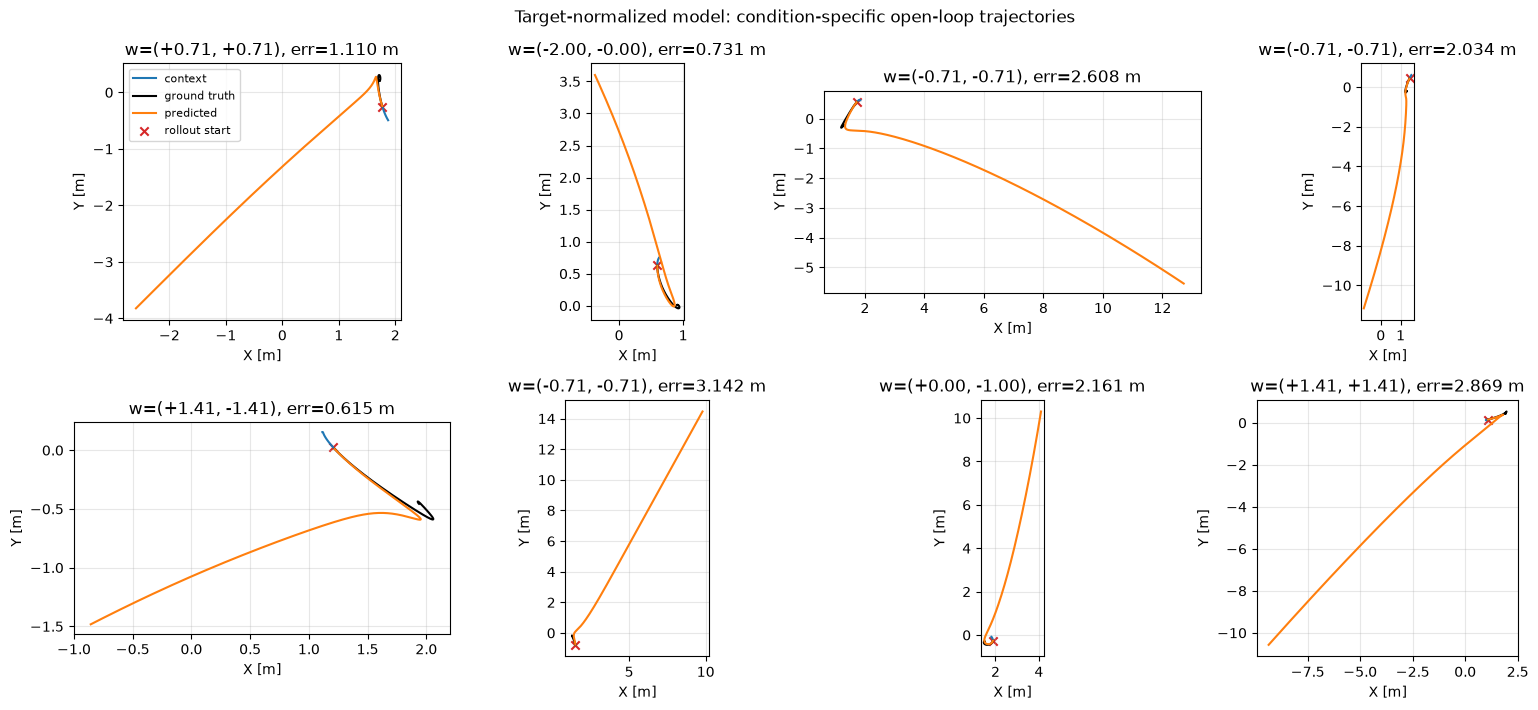

In [109]:
# The paper-style protocol is unchanged: infer one latent from the measured
# context, hold it fixed, and replay the same actions recursively for 5 s.
def target_normalized_learned_open_loop(
    initial_state, initial_context, action_sequence, step_keys
):
    fixed_latent = trajectory_encoder.apply(
        target_normalized_train_state.params["encoder"], initial_context
    )

    def learned_step(predicted_state, step_inputs):
        action, step_key = step_inputs
        current_state = state_vectors(
            predicted_state.quadrotor_state.p,
            predicted_state.quadrotor_state.R,
            predicted_state.quadrotor_state.v,
        )
        normalized_state_action = (
            jnp.concatenate([current_state, action], axis=-1) - input_mean
        ) / input_std
        prior_transition = prior_env._step(
            predicted_state, action, {}, step_key
        )
        prior_quad_state = prior_transition.state.quadrotor_state
        predicted_residual_norm = residual_model.apply(
            target_normalized_train_state.params["residual"],
            normalized_state_action,
            fixed_latent,
        )
        predicted_residual = (
            predicted_residual_norm * residual_target_std
            + residual_target_mean
        )
        corrected_quad_state = prior_quad_state.replace(
            p=prior_quad_state.p + predicted_residual[:3],
            v=prior_quad_state.v + predicted_residual[3:6],
        )
        corrected_state = prior_transition.state.replace(
            quadrotor_state=corrected_quad_state
        )
        return corrected_state, (corrected_quad_state, predicted_residual)

    _, outputs = jax.lax.scan(
        learned_step,
        initial_state,
        (action_sequence, step_keys),
    )
    predicted_states, predicted_residuals = outputs
    return predicted_states, predicted_residuals, fixed_latent

evaluate_target_normalized_open_loop = jax.jit(
    jax.vmap(target_normalized_learned_open_loop)
)
(
    target_normalized_open_loop_states,
    target_normalized_open_loop_residuals,
    target_normalized_open_loop_latents,
) = evaluate_target_normalized_open_loop(
    open_loop_initial_states,
    open_loop_initial_contexts,
    open_loop_actions,
    open_loop_keys,
)
target_normalized_open_loop_states.p.block_until_ready()

# Paper-style dynamics error: Euclidean position error at each open-loop
# timestep. Average over time within each rollout, then over rollouts so
# every trajectory receives equal weight regardless of valid duration.
open_loop_position_error = jnp.linalg.norm(
    target_normalized_open_loop_states.p - open_loop_true_states.p,
    axis=-1,
)
masked_open_loop_position_error = jnp.where(
    open_loop_valid_mask, open_loop_position_error, jnp.nan
)
per_rollout_cumulative_dynamics_error = (
    jnp.nansum(masked_open_loop_position_error, axis=1)
    / jnp.maximum(open_loop_valid_mask.sum(axis=1), 1)
)
cumulative_dynamics_error = jnp.mean(
    per_rollout_cumulative_dynamics_error
)
cumulative_dynamics_error_std = jnp.std(
    per_rollout_cumulative_dynamics_error
)
open_loop_winds = one_step_env_states.hidden_acceleration[
    open_loop_rollout_indices, 0, :
]
print("Paper-style open-loop cumulative dynamics error:")
print(
    f"  mean Euclidean position error: "
    f"{cumulative_dynamics_error:.6e} +/- "
    f"{cumulative_dynamics_error_std:.6e} m"
)
for rollout_index, (wind, rollout_error) in enumerate(zip(
    open_loop_winds, per_rollout_cumulative_dynamics_error
)):
    print(
        f"  rollout {rollout_index}: "
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}) m/s^2, "
        f"error={float(rollout_error):.6e} m"
    )

# Match the paper's condition-specific XY visualization instead of
# averaging residual magnitudes across unrelated trajectories.
num_open_loop_plots = open_loop_rollout_indices.shape[0]
num_plot_columns = min(4, num_open_loop_plots)
num_plot_rows = (num_open_loop_plots + num_plot_columns - 1) // num_plot_columns
fig, axes = plt.subplots(
    num_plot_rows, num_plot_columns,
    figsize=(4.0 * num_plot_columns, 3.6 * num_plot_rows),
    squeeze=False,
)
flat_axes = axes.ravel()
for plot_index in range(num_open_loop_plots):
    ax = flat_axes[plot_index]
    rollout_id = open_loop_rollout_indices[plot_index]
    context_positions = one_step_quad_states.p[
        rollout_id, :context_length + 1
    ]
    true_positions = open_loop_true_states.p[plot_index]
    predicted_positions = target_normalized_open_loop_states.p[plot_index]
    valid_steps = open_loop_valid_mask[plot_index]
    wind = open_loop_winds[plot_index]
    ax.plot(
        context_positions[:, 0], context_positions[:, 1],
        label="context", color="C0",
    )
    ax.plot(
        jnp.where(valid_steps, true_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, true_positions[:, 1], jnp.nan),
        label="ground truth", color="black",
    )
    ax.plot(
        jnp.where(valid_steps, predicted_positions[:, 0], jnp.nan),
        jnp.where(valid_steps, predicted_positions[:, 1], jnp.nan),
        label="predicted", color="C1",
    )
    ax.scatter(
        context_positions[-1, 0], context_positions[-1, 1],
        marker="x", color="C3", label="rollout start",
    )
    ax.set_title(
        f"w=({float(wind[0]):+.2f}, {float(wind[1]):+.2f}), "
        f"err={float(per_rollout_cumulative_dynamics_error[plot_index]):.3f} m"
    )
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
for unused_axis in flat_axes[num_open_loop_plots:]:
    unused_axis.set_visible(False)
flat_axes[0].legend(fontsize=8)
fig.suptitle(
    "Target-normalized model: condition-specific open-loop trajectories"
)
fig.tight_layout()
plt.show()


## 14. Save the Target-Normalized Model

Save the jointly trained encoder, residual dynamics, auxiliary decoder, and all normalization statistics required for inference.

In [110]:
from pathlib import Path

overwrite_existing_checkpoint = True
checkpoint_root = (
    Path(LOTF_PATH).parent / "checkpoints" / "residual_dynamics_encoder"
).resolve()
checkpoint_root.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_root / "normalized_residual_targets"

architecture = {
    "state_action_dim": jnp.asarray(state_action_dim),
    "context_length": jnp.asarray(context_length),
    "latent_dim": jnp.asarray(latent_dim),
    "encoder_projection_dim": jnp.asarray(128),
    "encoder_hidden_dim": jnp.asarray(128),
    "residual_hidden_dim": jnp.asarray(256),
    "residual_num_blocks": jnp.asarray(2),
    "predict_orientation": jnp.asarray(False),
}
target_normalized_checkpoint = {
    "params": target_normalized_train_state.params,
    "input_mean": input_mean,
    "input_std": input_std,
    "residual_target_mean": residual_target_mean,
    "residual_target_std": residual_target_std,
    "architecture": architecture,
    "simulation_dt": jnp.asarray(sim_dt),
    "environment_delay": jnp.asarray(0.04),
    "targets_are_normalized": jnp.asarray(True),
}
if checkpoint_path.exists() and not overwrite_existing_checkpoint:
    raise FileExistsError(
        f"Checkpoint already exists: {checkpoint_path}. "
        "Set overwrite_existing_checkpoint=True to replace it."
    )
PyTreeCheckpointer().save(
    checkpoint_path,
    target_normalized_checkpoint,
    force=overwrite_existing_checkpoint,
)
print(f"Saved target-normalized model to {checkpoint_path}")


Saved target-normalized model to /home/dimitria/PhD_codes/learning_on_the_fly/checkpoints/residual_dynamics_encoder/normalized_residual_targets
